# MNIST: 0〜4で UMAP 学習 → テスト(0〜9)を変換・可視化

実行時間を抑えるため、以下の設定で実験します。
- UMAP 学習用データ: ラベル 0〜4 の合計 500 サンプル（各クラス100件ずつ）
- 変換・可視化対象: 残りの 0〜9 を各 500 サンプルまで（存在すれば）
- UMAP パラメータ: 次元数=2, n_neighbors=30, min_dist=0.1, metric='euclidean', seed=42

UMAP 実装は `src/utils.py` の `_run_umap` を使用し、MNIST データは `src/load_data.py` の `_load_mnist_df` を用います。

In [1]:
# 軽い依存関係チェック（重い処理は行わない）
import sys, os
from pathlib import Path

# このノートブックは src/ 配下に置いている想定。
# もし実行ディレクトリが異なる場合に備えて、src を sys.path に追加。
repo_root = Path.cwd()
if (repo_root / 'src').exists():
    if str(repo_root / 'src') not in sys.path:
        sys.path.append(str(repo_root / 'src'))

try:
    import load_data, utils
    print('OK: modules imported (load_data, utils)')
except Exception as e:
    print('Import error:', e)

try:
    import umap
    print('OK: umap-learn is available:', getattr(umap, '__version__', 'unknown'))
except Exception as e:
    print('UMAP not available. Please install umap-learn (pip install umap-learn).')
    raise

OK: modules imported (load_data, utils)
OK: umap-learn is available: 0.5.9.post2


In [2]:
# MNIST を DataFrame で取得（features + 'target' 列）
import pandas as pd
import numpy as np

df = load_data._load_mnist_df()
print(df.shape, df.columns[:5], '... target in columns:', 'target' in df.columns)
# 特徴行列 X, ラベル y
y = df['target'].astype(int).to_numpy()
X = df.drop(columns=['target']).to_numpy(dtype=np.float32)
X.shape, y.shape

(70000, 785) Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5'], dtype='object') ... target in columns: True


((70000, 784), (70000,))

In [11]:
# サンプリング設定（学習: 0〜4 合計500件 = 各100件、テスト: 残り0〜9 各500件まで）
rng = np.random.default_rng(42)
train_total = 2000
train_classes = list(range(5))  # 0..4
train_per_class = max(1, train_total // len(train_classes))  # 100
per_class_limit = 500  # テスト各クラス上限

# 学習インデックス
train_idxs = []
for lab in train_classes:
    idx = np.where(y == lab)[0]
    rng.shuffle(idx)
    train_idxs.append(idx[:train_per_class])
train_idx = np.concatenate(train_idxs)

# テストインデックス（学習に使った分を除いた残りから、0..9 各500件）
all_test_idxs = []
used = set(train_idx.tolist())
for lab in range(10):
    idx = np.where(y == lab)[0]
    # 学習で使ったインデックスを除外
    idx = np.array([i for i in idx if i not in used], dtype=int)
    rng.shuffle(idx)
    all_test_idxs.append(idx[:per_class_limit])

test_idx = np.concatenate(all_test_idxs)

X_train = X[train_idx]
y_train = y[train_idx]
X_test  = X[test_idx]
y_test  = y[test_idx]

X_train.shape, X_test.shape

((500, 784), (5000, 784))

In [12]:
# utils._run_umap を使って 2 次元に削減（UMAP は fit→transform）
from types import SimpleNamespace

cfg = SimpleNamespace(
    max_umap_nb=30,           # 80 -> 30 に
    umap_min_dist=0.1,
    umap_metric='euclidean',
    seed=42,
    umap_transform_mode='embedding',   # 追加
    umap_repulsion_strength=0.5        # 追加
)

Xt, Xv, _, _ = utils._run_umap(
    X_train, X_test, n_components=2, config=cfg
)
Xt.shape, Xv.shape

((500, 2), (5000, 2))

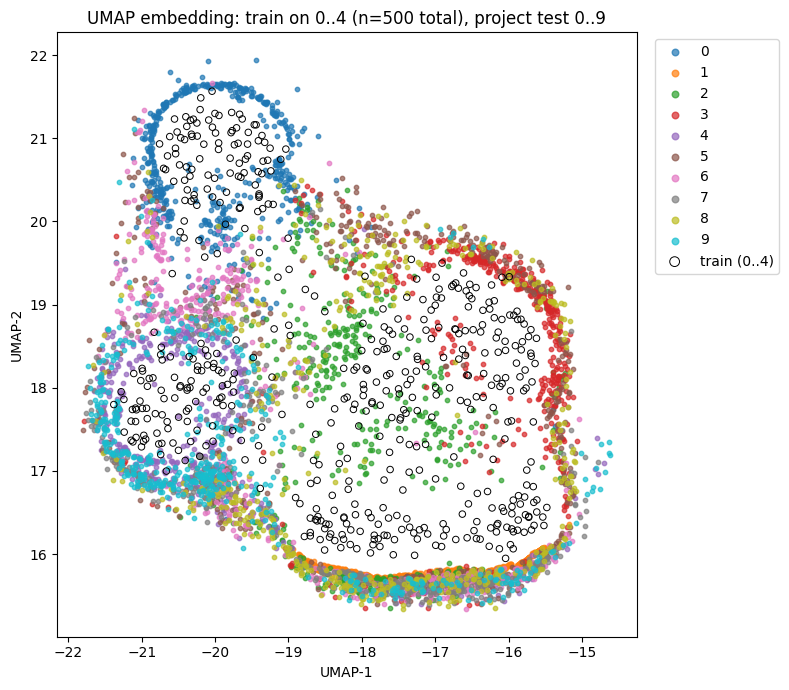

In [13]:
# 可視化（単一軸で0..9を色分け）
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,7))
# テスト（0..9）を色分け
palette = {0:'#1f77b4', 1:'#ff7f0e', 2:'#2ca02c', 3:'#d62728', 4:'#9467bd',
           5:'#8c564b', 6:'#e377c2', 7:'#7f7f7f', 8:'#bcbd22', 9:'#17becf'}
labels = y_test
for lab in range(10):
    mask = labels == lab
    if mask.sum() > 0:
        plt.scatter(Xv[mask,0], Xv[mask,1], s=10, c=palette.get(lab, 'gray'), label=str(lab), alpha=0.7)

# 学習に使った 0..4 は強調枠表示
plt.scatter(Xt[:,0], Xt[:,1], s=22, c='none', edgecolors='black', linewidths=0.7, label='train (0..4)')

plt.title('UMAP embedding: train on 0..4 (n=500 total), project test 0..9')
plt.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.tight_layout()
plt.show()

In [33]:
# サンプリング設定（学習: 0〜4 合計500件 = 各100件、テスト: 残り0〜9 各500件まで）
rng = np.random.default_rng(42)
train_total = 2000
train_classes = list(range(5, 10))  # 0..4
train_per_class = max(1, train_total // len(train_classes))  # 100
per_class_limit = 500  # テスト各クラス上限

# 学習インデックス
train_idxs = []
for lab in train_classes:
    idx = np.where(y == lab)[0]
    rng.shuffle(idx)
    train_idxs.append(idx[:train_per_class])
train_idx = np.concatenate(train_idxs)

# テストインデックス（学習に使った分を除いた残りから、0..9 各500件）
all_test_idxs = []
used = set(train_idx.tolist())
for lab in range(10):
    idx = np.where(y == lab)[0]
    # 学習で使ったインデックスを除外
    idx = np.array([i for i in idx if i not in used], dtype=int)
    rng.shuffle(idx)
    all_test_idxs.append(idx[:per_class_limit])

test_idx = np.concatenate(all_test_idxs)

X_train = X[train_idx]
y_train = y[train_idx]
X_test  = X[test_idx]
y_test  = y[test_idx]

X_train.shape, X_test.shape

# utils._run_umap を使って 2 次元に削減（UMAP は fit→transform）
from types import SimpleNamespace

cfg = SimpleNamespace(
    max_umap_nb=30,           # 80 -> 30 に
    umap_min_dist=0.1,
    umap_metric='euclidean',
    seed=42,
    umap_transform_mode='embedding',   # 追加
    umap_repulsion_strength=0.5        # 追加
)

Xt, Xv, _, _ = utils._run_umap(
    X_train, X_test, n_components=2, config=cfg
)
Xt.shape, Xv.shape

((2000, 2), (5000, 2))

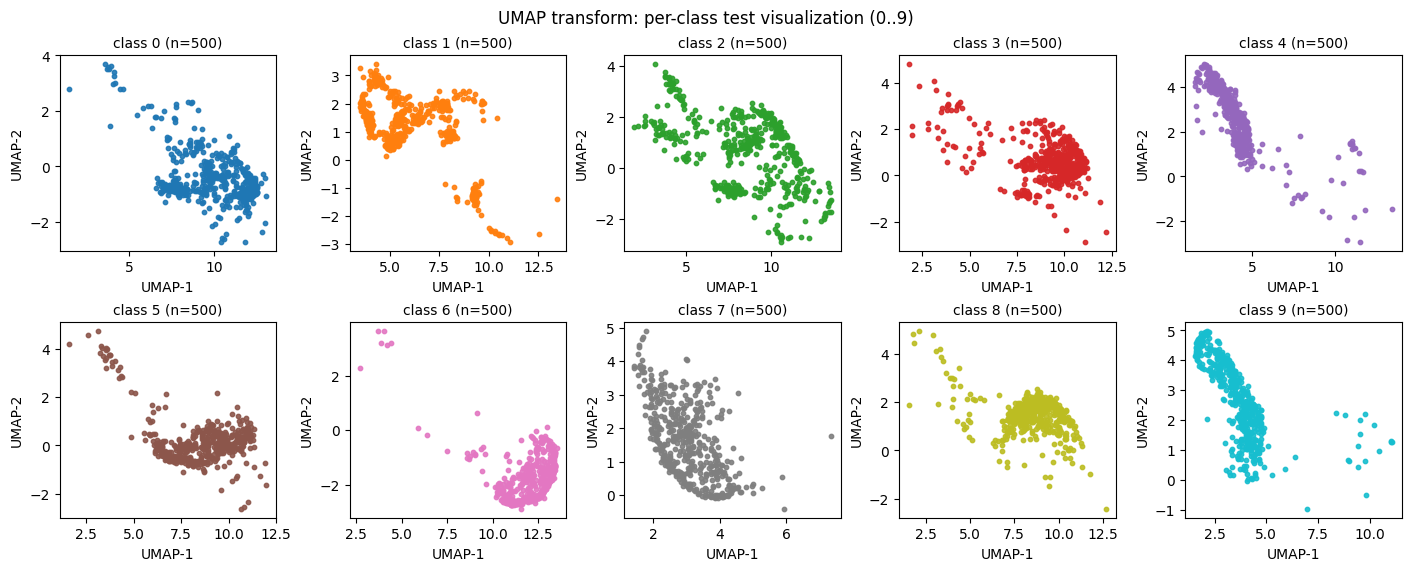

In [34]:
# クラスごとに別々の図に可視化（2x5グリッドで 0〜9）
import matplotlib.pyplot as plt
import numpy as np

# 必要なら学習に使った 0 を薄い背景として描く
show_train_bg = False  # True にすると学習0を薄灰で背景表示

labels = y_test
classes = list(range(10))
cols = 5
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 5.6), constrained_layout=True)
axes = axes.flatten()

palette = {
    0:'#1f77b4', 1:'#ff7f0e', 2:'#2ca02c', 3:'#d62728', 4:'#9467bd',
    5:'#8c564b', 6:'#e377c2', 7:'#7f7f7f', 8:'#bcbd22', 9:'#17becf'
}

for i, lab in enumerate(classes):
    ax = axes[i]
    mask = labels == lab
    if show_train_bg and Xt is not None:
        ax.scatter(Xt[:,0], Xt[:,1], s=4, c='#cccccc', alpha=0.25, linewidths=0, label='0 (train bg)')
    if mask.sum() > 0:
        ax.scatter(Xv[mask,0], Xv[mask,1], s=10, c=palette.get(lab, 'gray'), alpha=0.9)
    ax.set_title(f'class {lab} (n={int(mask.sum())})', fontsize=10)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')

# 余りのサブプロットを非表示（保険）
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

fig.suptitle('UMAP transform: per-class test visualization (0..9)', fontsize=12)
plt.show()

# AE/KPCA 潜在表現に UMAP(2D) を適用し、クラス別(2x5)に可視化

このセクションでは、
- AutoEncoder で 13次元に圧縮した潜在表現 → UMAP 2D
- KernelPCA で 13次元に圧縮した潜在表現 → UMAP 2D
を作成し、0〜9 の各クラスを 2x5 のサブプロットで表示します。

In [ ]:
# AE 13D → UMAP 2D を作成
from types import SimpleNamespace

# まず AE の 13D が無ければ生成
if 'Xt13_ae' not in globals() or Xt13_ae is None:
    cfg_ae = SimpleNamespace(ae_epochs=15, ae_batch=256, seed=42)
    Xt13_ae, Xv13_ae, _, _ = utils._run_autoencoder(
        X_train, X_test, n_components=13, config=cfg_ae
    )

# AE 13D に UMAP 2D を適用
cfg_um = SimpleNamespace(max_umap_nb=30, umap_min_dist=0.1, umap_metric='euclidean',
                         seed=42, umap_transform_mode='embedding', umap_repulsion_strength=0.5)
Xt2_ae_um, Xv2_ae_um, _, _ = utils._run_umap(
    Xt13_ae, Xv13_ae, n_components=2, config=cfg_um
)
print('AE->UMAP shapes:', Xt2_ae_um.shape, Xv2_ae_um.shape)

# AutoEncoder 直接2次元（UMAPやPCAを使わずに2D潜在へ）

AutoEncoder の潜在次元を 2 に設定し、そのまま可視化します。
- 学習: 0..4（既存の `X_train`/`y_train`）
- テスト: 0..9（`X_test`/`y_test`）

In [27]:
# AE 直接2Dの埋め込みを作成
from types import SimpleNamespace

cfg_ae2 = SimpleNamespace(ae_epochs=15, ae_batch=256, seed=42)
Xt2_ae_direct, Xv2_ae_direct, _, _ = utils._run_autoencoder(
    X_train, X_test, n_components=2, config=cfg_ae2
)
print('AE 2D shapes:', Xt2_ae_direct.shape, Xv2_ae_direct.shape)

AE 2D shapes: (2000, 2) (5000, 2)


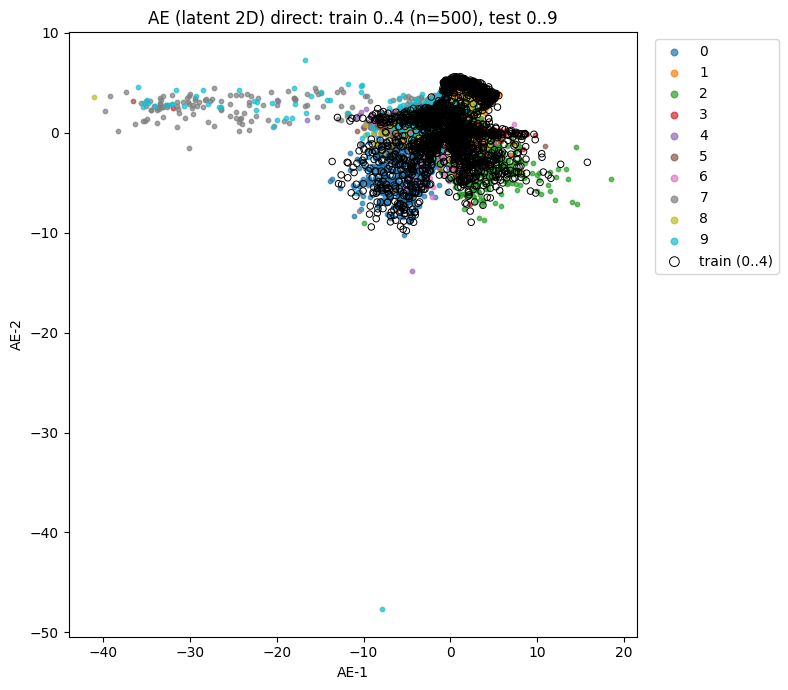

In [28]:
# 可視化（AE 2D 直接, 単一軸で0..9を色分け）
import matplotlib.pyplot as plt

plt.figure(figsize=(8,7))
palette = {0:'#1f77b4', 1:'#ff7f0e', 2:'#2ca02c', 3:'#d62728', 4:'#9467bd',
           5:'#8c564b', 6:'#e377c2', 7:'#7f7f7f', 8:'#bcbd22', 9:'#17becf'}
labels = y_test
for lab in range(10):
    mask = (labels == lab)
    if mask.sum() > 0:
        plt.scatter(Xv2_ae_direct[mask,0], Xv2_ae_direct[mask,1], s=10, c=palette.get(lab, 'gray'), label=str(lab), alpha=0.7)
plt.scatter(Xt2_ae_direct[:,0], Xt2_ae_direct[:,1], s=22, c='none', edgecolors='black', linewidths=0.7, label='train (0..4)')
plt.title('AE (latent 2D) direct: train 0..4 (n=500), test 0..9')
plt.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel('AE-1'); plt.ylabel('AE-2')
plt.tight_layout()
plt.show()

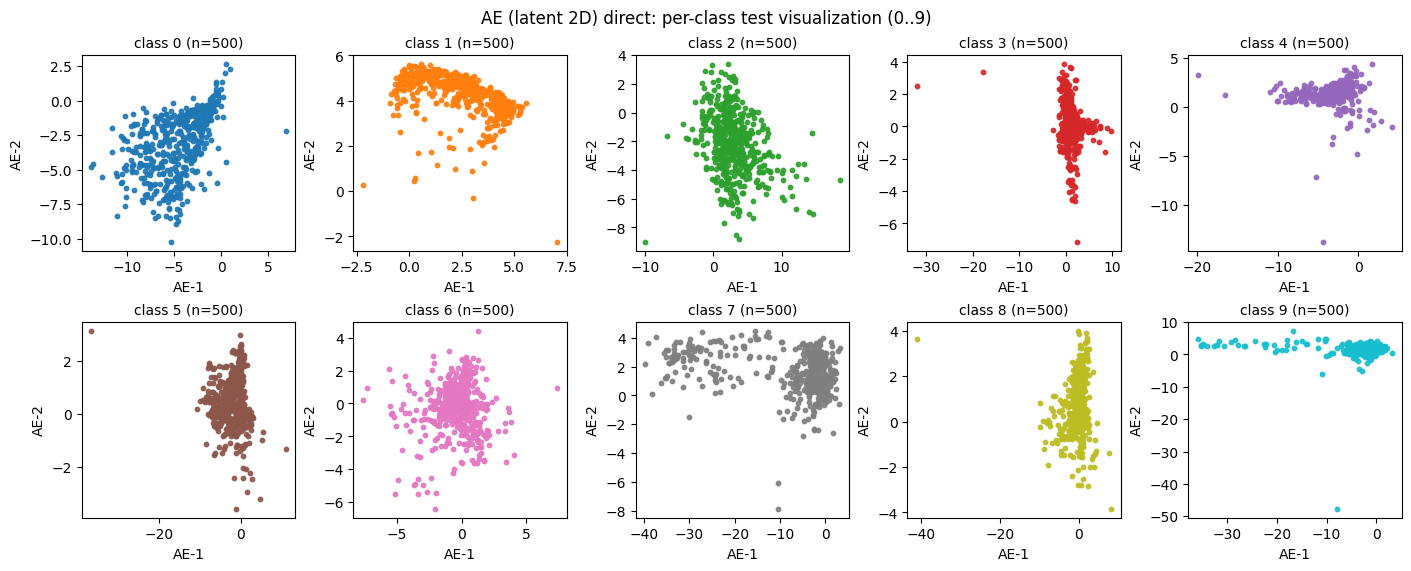

In [29]:
# AE 2D 直接: クラスごとに別々の図（2x5）
import matplotlib.pyplot as plt
import numpy as np

labels = y_test
classes = list(range(10))
cols, rows = 5, 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 5.6), constrained_layout=True)
axes = axes.flatten()

palette = {0:'#1f77b4', 1:'#ff7f0e', 2:'#2ca02c', 3:'#d62728', 4:'#9467bd',
           5:'#8c564b', 6:'#e377c2', 7:'#7f7f7f', 8:'#bcbd22', 9:'#17becf'}

for i, lab in enumerate(classes):
    ax = axes[i]
    mask = labels == lab
    if mask.sum() > 0:
        ax.scatter(Xv2_ae_direct[mask,0], Xv2_ae_direct[mask,1], s=10, c=palette.get(lab, 'gray'), alpha=0.9)
    ax.set_title(f'class {lab} (n={int(mask.sum())})', fontsize=10)
    ax.set_xlabel('AE-1'); ax.set_ylabel('AE-2')

for j in range(len(classes), len(axes)):
    axes[j].axis('off')

fig.suptitle('AE (latent 2D) direct: per-class test visualization (0..9)', fontsize=12)
plt.show()

# === Fashion-MNIST: KernelPCA (per-label fit) + Linear SVM + gamma grid AUC ===
# 実験概要:
# - データ: Fashion-MNIST (OpenML)
# - 分割: stratified 7:3
# - 各ラベルℓごとに、学習データのうちℓに属するサンプルだけでKernelPCA(RBF)をfit
# - そのKPCAで全ラベルの学習/テストをtransform → 線形SVMで one-vs-rest を学習・AUC計測
# - RBFのgammaをグリッドサーチし、"全体(macro mean)AUC"を最大化するgammaを選択
# - そのときの ℓのAUC、その他クラス平均AUC、全体AUC を記録

In [2]:
from typing import Iterable, Dict, Tuple
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score
from load_data import _load_fashion_mnist_df

# 設定
SEED = 42
rng = np.random.default_rng(SEED)

# データ読み込み（DataFrame: 784列 + target）
df_f = _load_fashion_mnist_df().copy()
# target が数値でない可能性に備えてエンコード
print(1)
le = LabelEncoder()
df_f["target"] = le.fit_transform(df_f["target"])  # 0..9
print(2)
X_all = df_f.drop(columns=["target"]).to_numpy(dtype=np.float32)
y_all = df_f["target"].to_numpy(dtype=int)
print(3)
# stratified 7:3 split
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.5, stratify=y_all, random_state=SEED
)
print(4)
# スケーリングは学習データでfit→全体に適用
scaler_f = StandardScaler()
X_tr = scaler_f.fit_transform(X_tr_raw)
X_te = scaler_f.transform(X_te_raw)
print(5)
classes_f = np.unique(y_all).tolist()
print("Fashion-MNIST split:", X_tr.shape, X_te.shape, "classes:", classes_f)

1
2
3
4
5
Fashion-MNIST split: (35000, 784) (35000, 784) classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
X_tr

In [5]:
from dataclasses import dataclass


def _sample_idx(idx: np.ndarray, cap: int, seed: int = 42) -> np.ndarray:
    if len(idx) <= cap:
        return idx
    rng = np.random.default_rng(seed)
    return rng.choice(idx, size=cap, replace=False)


@dataclass
class KPCAConfig:
    n_components: int = 13
    gamma_grid: Iterable[float] = tuple(np.logspace(-3, -1, 5))  # 1e-3..1e-1
    fit_cap_per_label: int = 800  # ラベルℓでKPCAをfitする際の上限（高速化のため）
    max_iter_svm: int = 5000


def run_kpca_svm_alllabels(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    cfg: KPCAConfig,
    seed: int = 42,
) -> Dict:
    """
    学習データの全ラベルを用いてRBF-KernelPCAをfit。
    gammaをグリッドサーチし、"全体(macro mean)AUC"を最大化するgammaを選ぶ。
    そのときの各クラスAUCの辞書も返す。
    戻り値: dict(best_gamma, overall_auc, auc_by_class)
    """
    classes = np.unique(np.concatenate([y_train, y_test]))
    best = {"overall_auc": -np.inf, "best_gamma": None, "auc_by_class": None}
    for gamma in cfg.gamma_grid:
        kp = KernelPCA(
            n_components=cfg.n_components,
            kernel="rbf",
            gamma=float(gamma),
            fit_inverse_transform=False,
            eigen_solver="auto",
        )
        kp.fit(X_train)
        Z_tr = kp.transform(X_train)
        Z_te = kp.transform(X_test)

        aucs = {}
        for c in classes:
            y_tr_bin = (y_train == c).astype(int)
            y_te_bin = (y_test == c).astype(int)
            clf = LinearSVC(C=1.0, class_weight="balanced", max_iter=cfg.max_iter_svm, random_state=seed)
            clf.fit(Z_tr, y_tr_bin)
            scores = clf.decision_function(Z_te)
            if len(np.unique(y_te_bin)) < 2:
                auc = np.nan
            else:
                auc = roc_auc_score(y_te_bin, scores)
            aucs[int(c)] = auc
        auc_vals = np.array([v for v in aucs.values() if not np.isnan(v)])
        overall = float(np.mean(auc_vals)) if len(auc_vals) else np.nan
        if overall > best["overall_auc"]:
            best.update({"overall_auc": overall, "best_gamma": float(gamma), "auc_by_class": aucs})
    return best


def run_kpca_svm_for_label(
    label: int,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    cfg: KPCAConfig,
    seed: int = 42,
    objective: str = "overall",  # "overall" or "selected"
) -> Dict:
    """
    ラベルlabelの学習データのみでRBF-KernelPCAをfit。
    その変換で全ラベルの学習/テストを埋め込み、各クラスのone-vs-rest線形SVMを学習してAUCを算出。
    gammaをグリッドサーチし、objectiveで指定した基準で最良のgammaを選ぶ。
      - objective="overall": 全体(macro mean)AUC最大
      - objective="selected": 指定labelのAUC最大
    戻り値: dict(label, best_gamma, selected_auc, others_mean_auc, overall_auc, auc_by_class)
    """
    classes = np.unique(np.concatenate([y_train, y_test]))
    best = {"score": -np.inf, "overall_auc": -np.inf, "best_gamma": None, "auc_by_class": None}

    # インデックス: labelの学習データのみ
    idx_lbl = np.where(y_train == label)[0]
    idx_fit = _sample_idx(idx_lbl, cfg.fit_cap_per_label, seed)

    for gamma in cfg.gamma_grid:
        kp = KernelPCA(n_components=cfg.n_components, kernel="rbf", gamma=float(gamma), fit_inverse_transform=False, eigen_solver="auto")
        kp.fit(X_train[idx_fit])  # 選択ラベルのみでfit
        Z_tr = kp.transform(X_train)
        Z_te = kp.transform(X_test)

        aucs = {}
        for c in classes:
            y_tr_bin = (y_train == c).astype(int)
            y_te_bin = (y_test == c).astype(int)
            clf = LinearSVC(C=1.0, class_weight="balanced", max_iter=cfg.max_iter_svm, random_state=seed)
            clf.fit(Z_tr, y_tr_bin)
            scores = clf.decision_function(Z_te)
            if len(np.unique(y_te_bin)) < 2:
                auc = np.nan
            else:
                auc = roc_auc_score(y_te_bin, scores)
            aucs[int(c)] = auc

        auc_vals = np.array([v for v in aucs.values() if not np.isnan(v)])
        overall = float(np.mean(auc_vals)) if len(auc_vals) else np.nan
        selected_auc_tmp = float(aucs.get(int(label), np.nan))
        score = overall if objective == "overall" else selected_auc_tmp

        if np.isfinite(score) and score > best["score"]:
            best.update({
                "score": float(score),
                "overall_auc": overall,
                "best_gamma": float(gamma),
                "auc_by_class": aucs,
            })

    aucs_best = best["auc_by_class"]
    selected_auc = float(aucs_best.get(int(label), np.nan))
    others = [v for k, v in aucs_best.items() if k != int(label) and not np.isnan(v)]
    others_mean = float(np.mean(others)) if others else np.nan

    return {
        "label": int(label),
        "best_gamma": best["best_gamma"],
        "selected_auc": selected_auc,
        "others_mean_auc": others_mean,
        "overall_auc": float(best["overall_auc"]),
        "auc_by_class": aucs_best,
        "objective": objective,
    }

In [3]:
# 実行: 各ラベルについてグリッドサーチ → 結果表（objective='overall' 版）
cfg_kp = KPCAConfig(
    n_components=13,
    gamma_grid=tuple(np.logspace(-5, -4, 1)),  # 1e-3..1e-1
    fit_cap_per_label=800,
)

results_overall = []
for lab in classes_f:
    res = run_kpca_svm_for_label(lab, X_tr, y_tr, X_te, y_te, cfg_kp, seed=SEED, objective="overall")
    results_overall.append(res)
    print(f"[overall] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

# 整形して表示・保存
overall_rows = []
for r in results_overall:
    overall_rows.append({k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]})
overall_df = pd.DataFrame(overall_rows).sort_values("label").reset_index(drop=True)
print(overall_df)

# 保存
from pathlib import Path
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fashion_kpca_linear_svm_auc_by_overall.csv"
overall_df.to_csv(out_path, index=False)
print("saved:", out_path)

[overall] label=0 -> gamma=1e-05, selAUC=0.9676, others=0.9480, overall=0.9499
[overall] label=1 -> gamma=1e-05, selAUC=0.9920, others=0.9369, overall=0.9424
[overall] label=1 -> gamma=1e-05, selAUC=0.9920, others=0.9369, overall=0.9424
[overall] label=2 -> gamma=1e-05, selAUC=0.9228, others=0.9459, overall=0.9436
[overall] label=2 -> gamma=1e-05, selAUC=0.9228, others=0.9459, overall=0.9436
[overall] label=3 -> gamma=1e-05, selAUC=0.9503, others=0.9499, overall=0.9500
[overall] label=3 -> gamma=1e-05, selAUC=0.9503, others=0.9499, overall=0.9500
[overall] label=4 -> gamma=1e-05, selAUC=0.9476, others=0.9475, overall=0.9475
[overall] label=4 -> gamma=1e-05, selAUC=0.9476, others=0.9475, overall=0.9475
[overall] label=5 -> gamma=1e-05, selAUC=0.9547, others=0.9248, overall=0.9278
[overall] label=5 -> gamma=1e-05, selAUC=0.9547, others=0.9248, overall=0.9278
[overall] label=6 -> gamma=1e-05, selAUC=0.7941, others=0.9603, overall=0.9437
[overall] label=6 -> gamma=1e-05, selAUC=0.7941, oth

In [6]:
# クイック検証ラン（時間短縮用）: 3ラベル・少数gamma・小さめfit_cap
QUICK = True
labels_run = classes_f[:3] if QUICK else classes_f
cfg_kp_quick = KPCAConfig(
    n_components=13,
    gamma_grid=tuple(np.logspace(-2.5, -1, 1)),  # ~[0.003, 0.01, 0.032]
    fit_cap_per_label=120,
)

results_quick = []
for lab in labels_run:
    res = run_kpca_svm_for_label(lab, X_tr, y_tr, X_te, y_te, cfg_kp_quick, seed=SEED)
    results_quick.append(res)
    print(f"[quick] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

rows_q = [{k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]} for r in results_quick]
res_quick_df = pd.DataFrame(rows_q).sort_values("label").reset_index(drop=True)
print(res_quick_df)

[quick] label=0 -> gamma=0.003162, selAUC=0.9320, others=0.9112, overall=0.9133
[quick] label=1 -> gamma=0.003162, selAUC=0.9722, others=0.8684, overall=0.8788
[quick] label=1 -> gamma=0.003162, selAUC=0.9722, others=0.8684, overall=0.8788
[quick] label=2 -> gamma=0.003162, selAUC=0.9155, others=0.9033, overall=0.9046
   label  best_gamma  selected_auc  others_mean_auc  overall_auc
0      0    0.003162      0.932030         0.911229     0.913309
1      1    0.003162      0.972178         0.868374     0.878754
2      2    0.003162      0.915543         0.903345     0.904565
[quick] label=2 -> gamma=0.003162, selAUC=0.9155, others=0.9033, overall=0.9046
   label  best_gamma  selected_auc  others_mean_auc  overall_auc
0      0    0.003162      0.932030         0.911229     0.913309
1      1    0.003162      0.972178         0.868374     0.878754
2      2    0.003162      0.915543         0.903345     0.904565


In [ ]:
# ベースライン: 全ラベルでKPCAをfit → per-class AUC を計測（最良gammaを全体AUCで選択）
cfg_kp_base = KPCAConfig(
    n_components=13,
    gamma_grid=tuple(np.logspace(-3, -1, 1)),  # 1e-3..1e-1（やや広め）
)

base = run_kpca_svm_alllabels(X_tr, y_tr, X_te, y_te, cfg_kp_base, seed=SEED)
print(f"[baseline-alllabels] best gamma={base['best_gamma']:.4g}, overall AUC={base['overall_auc']:.4f}")
# per-class の表
base_rows = [{"label": int(k), "auc": float(v)} for k, v in base["auc_by_class"].items()]
base_df = pd.DataFrame(base_rows).sort_values("label").reset_index(drop=True)
print(base_df)

# 保存
from pathlib import Path
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
base_path = out_dir / "fashion_kpca_alllabels_linear_svm_auc.csv"
base_df.assign(best_gamma=base["best_gamma"], overall_auc=base["overall_auc"]).to_csv(base_path, index=False)
print("saved:", base_path)

In [ ]:
# 実行: 各ラベルについてグリッドサーチ → 結果表（objective='selected' 版：各ラベルのAUC最大化）
cfg_kp_sel = KPCAConfig(
    n_components=13,
    gamma_grid=tuple(np.logspace(-3, -1, 1)),
    fit_cap_per_label=800,
)

results_selected = []
for lab in classes_f:
    res = run_kpca_svm_for_label(lab, X_tr, y_tr, X_te, y_te, cfg_kp_sel, seed=SEED, objective="selected")
    results_selected.append(res)
    print(f"[selected] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

sel_rows = []
for r in results_selected:
    sel_rows.append({k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]})
selected_df = pd.DataFrame(sel_rows).sort_values("label").reset_index(drop=True)
print(selected_df)

# 保存
from pathlib import Path
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
out_path_sel = out_dir / "fashion_kpca_linear_svm_auc_by_selected.csv"
selected_df.to_csv(out_path_sel, index=False)
print("saved:", out_path_sel)

In [5]:
# ベースライン（軽量版・検証用）: 学習の一部サンプルでKPCAをfit
cfg_kp_base_quick = KPCAConfig(
    n_components=13,
    gamma_grid=tuple(np.logspace(-2.5, -1, 3)),  # 約[0.003, 0.01, 0.032]
)
cap = 5000
rng = np.random.default_rng(SEED)
idx_sub = rng.choice(np.arange(X_tr.shape[0]), size=min(cap, X_tr.shape[0]), replace=False)

best_q = {"overall_auc": -np.inf, "best_gamma": None, "auc_by_class": None}
for gamma in cfg_kp_base_quick.gamma_grid:
    kp = KernelPCA(n_components=cfg_kp_base_quick.n_components, kernel="rbf", gamma=float(gamma))
    kp.fit(X_tr[idx_sub])
    Z_tr = kp.transform(X_tr)
    Z_te = kp.transform(X_te)
    aucs = {}
    for c in np.unique(y_all):
        y_tr_bin = (y_tr == c).astype(int)
        y_te_bin = (y_te == c).astype(int)
        clf = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, random_state=SEED)
        clf.fit(Z_tr, y_tr_bin)
        scores = clf.decision_function(Z_te)
        if len(np.unique(y_te_bin)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_te_bin, scores)
        aucs[int(c)] = auc
    vals = np.array([v for v in aucs.values() if not np.isnan(v)])
    m = float(np.mean(vals)) if len(vals) else np.nan
    if m > best_q["overall_auc"]:
        best_q.update({"overall_auc": m, "best_gamma": float(gamma), "auc_by_class": aucs})

print(f"[baseline-quick] best gamma={best_q['best_gamma']:.4g}, overall AUC={best_q['overall_auc']:.4f}")
base_q_rows = [{"label": int(k), "auc": float(v)} for k, v in best_q["auc_by_class"].items()]
base_q_df = pd.DataFrame(base_q_rows).sort_values("label").reset_index(drop=True)
print(base_q_df)

[baseline-quick] best gamma=0.003162, overall AUC=0.9460
   label       auc
0      0  0.961662
1      1  0.988588
2      2  0.904163
3      3  0.968115
4      4  0.923280
5      5  0.957590
6      6  0.831336
7      7  0.986841
8      8  0.964705
9      9  0.973613


In [7]:
# クイック検証ラン（selected目的）: 3ラベル・少数gamma
QUICK = True
labels_run = classes_f[:3] if QUICK else classes_f
cfg_kp_quick_sel = KPCAConfig(
    n_components=13,
    gamma_grid=tuple(np.logspace(-2.5, -1, 3)),
    fit_cap_per_label=120,
)

results_quick_sel = []
for lab in labels_run:
    res = run_kpca_svm_for_label(lab, X_tr, y_tr, X_te, y_te, cfg_kp_quick_sel, seed=SEED, objective="selected")
    results_quick_sel.append(res)
    print(f"[quick-selected] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

rows_qs = [{k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]} for r in results_quick_sel]
res_quick_sel_df = pd.DataFrame(rows_qs).sort_values("label").reset_index(drop=True)
print(res_quick_sel_df)

: 

## 最終実験: 各ラベルのAUC（選択ラベル）最大化になるようにKernelPCAのγをチューニング
- Fashion-MNIST を 7:3 で分割済み（上セル）
- 各ラベルℓの学習データのみで RBF-KernelPCA を fit
- γ をグリッドサーチし、目的関数 = 選択ラベルℓの AUC を最大化
- 学習: 変換後の特徴で One-vs-Rest 線形SVM を学習し、テスト AUC を計測
- 出力: label, best_gamma, selected_auc, others_mean_auc, overall_auc をCSV保存

In [6]:
# 実行セル（選択ラベルAUC最大化）: 時間短縮のQUICKトグル付き
QUICK = False  # フル実行にする場合は False に変更してください
labels_run = classes_f if not QUICK else classes_f[:3]

# グリッド（QUICK時は粗く、フル時は少し細かく）
GAMMA_GRID = tuple(np.logspace(-5, -3, 3)) if not QUICK else tuple(np.logspace(-5, -4, 2))
FIT_CAP = 800 if not QUICK else 120

In [7]:
cfg_sel_final = KPCAConfig(
    n_components=13,
    gamma_grid=GAMMA_GRID,
    fit_cap_per_label=FIT_CAP,
)

In [9]:
results_sel_final = []
for lab in labels_run:
    res = run_kpca_svm_for_label(
        lab, X_tr, y_tr, X_te, y_te, cfg_sel_final, seed=SEED, objective="selected"
    )
    results_sel_final.append(res)
    print(f"[final-selected] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

[final-selected] label=0 -> gamma=1e-05, selAUC=0.9634, others=0.9452, overall=0.9471
[final-selected] label=1 -> gamma=0.0001, selAUC=0.9914, others=0.9333, overall=0.9391
[final-selected] label=2 -> gamma=0.0001, selAUC=0.9282, others=0.9493, overall=0.9472
[final-selected] label=3 -> gamma=0.0001, selAUC=0.9560, others=0.9501, overall=0.9507
[final-selected] label=4 -> gamma=0.0001, selAUC=0.9511, others=0.9477, overall=0.9481
[final-selected] label=5 -> gamma=0.0001, selAUC=0.9551, others=0.9234, overall=0.9266
[final-selected] label=6 -> gamma=0.0001, selAUC=0.8143, others=0.9628, overall=0.9480
[final-selected] label=7 -> gamma=0.001, selAUC=0.9840, others=0.8963, overall=0.9051
[final-selected] label=8 -> gamma=0.001, selAUC=0.9769, others=0.9365, overall=0.9405
[final-selected] label=9 -> gamma=0.0001, selAUC=0.9865, others=0.9183, overall=0.9251


In [10]:
final_df = pd.DataFrame([
    {k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]}
    for r in results_sel_final
]).sort_values("label").reset_index(drop=True)
print(final_df)


   label  best_gamma  selected_auc  others_mean_auc  overall_auc
0      0    0.000016      0.967674         0.948740     0.950633
1      1    0.000016      0.992116         0.938128     0.943527
2      2    0.000016      0.922836         0.946531     0.944162
3      3    0.001000      0.957375         0.945996     0.947134
4      4    0.000063      0.948597         0.948607     0.948606
5      5    0.000016      0.954698         0.925779     0.928671
6      6    0.001000      0.815700         0.960853     0.946338
7      7    0.001000      0.982686         0.882310     0.892348
8      8    0.001000      0.977779         0.933473     0.937904
9      9    0.000251      0.982496         0.907784     0.915256


In [11]:
# 保存
from pathlib import Path
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
final_path = out_dir / "fashion_kpca_linear_svm_auc_selected_final.csv"
final_df.to_csv(final_path, index=False)
print("saved:", final_path)

saved: output\fashion_kpca_linear_svm_auc_selected_final.csv


In [4]:
# 実行セル（選択ラベルAUC最大化）: 時間短縮のQUICKトグル付き
QUICK = True  # フル実行にする場合は False に変更してください
labels_run = classes_f if not QUICK else classes_f[:3]

# グリッド（QUICK時は粗く、フル時は少し細かく）
GAMMA_GRID = tuple(np.logspace(-3, -1, 7)) if not QUICK else tuple(np.logspace(-2.5, -1, 3))
FIT_CAP = 800 if not QUICK else 120

cfg_sel_final = KPCAConfig(
    n_components=13,
    gamma_grid=GAMMA_GRID,
    fit_cap_per_label=FIT_CAP,
)

results_sel_final = []
for lab in labels_run:
    res = run_kpca_svm_for_label(
        lab, X_tr, y_tr, X_te, y_te, cfg_sel_final, seed=SEED, objective="selected"
    )
    results_sel_final.append(res)
    print(f"[final-selected] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

final_df = pd.DataFrame([
    {k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]}
    for r in results_sel_final
]).sort_values("label").reset_index(drop=True)
print(final_df)

# 保存
from pathlib import Path
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
final_path = out_dir / "fashion_kpca_linear_svm_auc_selected_final.csv"
final_df.to_csv(final_path, index=False)
print("saved:", final_path)

: 

In [20]:
# COIL-20の 1 番ディレクトリの画像をKPCAで1次元に削減し、値が小さい順に並べたインデックスとファイル名を出力
from pathlib import Path
import numpy as np
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA

# データディレクトリ
data_dir = Path("input/archive/coil-20/1")

# 画像読み込み（よくある拡張子を対象）
exts = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.pgm", "*.ppm")
files = sorted([p for ext in exts for p in data_dir.glob(ext)])
if len(files) == 0:
    raise FileNotFoundError(f"No image files found in: {data_dir}")

# 画像をグレースケール化してフラット化
X_list, names = [], []
for p in files:
    img = Image.open(p).convert("L")  # グレースケール
    arr = np.asarray(img, dtype=np.float32).ravel()
    X_list.append(arr)
    names.append(p.name)

X = np.vstack(X_list)  # shape: (n_images, n_pixels)

# スケーリング → KernelPCA(1D)
scaler = StandardScaler()
Xn = scaler.fit_transform(X)

# gammaは次元に依存するので 1/次元 を初期値に
gamma = 1.0 / Xn.shape[1]
kp = KernelPCA(n_components=1, kernel="rbf", gamma=gamma, fit_inverse_transform=False)
z1d = kp.fit_transform(Xn).ravel()  # shape: (n_images,)

# 1次元の値が小さい順に並べ替え
order = np.argsort(z1d)

# 出力（rank: 並び順, idx: 元リストのインデックス, name: ファイル名, z: 1次元値）
print(f"Total images: {len(files)} from {data_dir}")
for rank, idx in enumerate(order, start=1):
    print(f"{rank:3d}: idx={idx:3d}, name={names[idx]}, z={z1d[idx]:.6f}")

FileNotFoundError: No image files found in: input\archive\coil-20\1

In [26]:
# COIL-20: ファイル名からラベルと回転数を抽出し、各ピクセルを1行に展開してCSVに保存（gzip圧縮）
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image

# 入力ルート（相対パス推奨）。例: input/archive/coil-20/obj1__0.png など
root = Path("input/archive/coil-20")
if not root.exists():
    # フォールバック: ユーザー環境の絶対パスがある場合はここに生値（raw string）で指定
    alt = Path(r"C:\\Users\\sueya\\Git-Repositories\\takano_labo\\dca\\input\\archive\\coil-20")
    root = alt if alt.exists() else root

if not root.exists():
    print(f"[WARN] 画像ディレクトリが見つかりません: {root}. パスを確認してください。")
else:
    # 画像ファイルの収集（サブディレクトリを含め、よくある拡張子を対象）
    exts = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.pgm", "*.ppm")
    files = []
    for ext in exts:
        files.extend(root.rglob(ext))
    files = sorted(files)

    if len(files) == 0:
        print(f"[WARN] 画像ファイルが見つかりません: {root}")
    else:
        # ラベル・回転数をファイル名から抽出: 例 obj1__0.png -> label=1, rotation=0
        pat = re.compile(r"obj(\d+)__([0-9]+)", re.IGNORECASE)

        # 最初の画像から画素数を取得してカラム名を作成
        img0 = Image.open(files[0]).convert("L")  # グレースケール
        w0, h0 = img0.size
        n_pix = w0 * h0
        pixel_cols = [f"pix_{i:05d}" for i in range(n_pix)]

        rows = []
        bad = 0
        for p in files:
            name = p.name
            m = pat.search(name)
            if m:
                label_id = int(m.group(1))
                rotation = int(m.group(2))
            else:
                # 親ディレクトリ名が数字のみならラベルとして使用、回転は0扱い
                parent = p.parent.name
                if parent.isdigit():
                    label_id = int(parent)
                    rotation = 0
                else:
                    bad += 1
                    continue

            # 画像を読み込み、サイズを統一（最初の画像と異なる場合はリサイズ）
            img = Image.open(p).convert("L")
            if img.size != (w0, h0):
                img = img.resize((w0, h0))
            arr = np.asarray(img, dtype=np.uint8).reshape(-1)  # 0..255

            if arr.size != n_pix:
                bad += 1
                continue

            row = {
                "label": label_id,
                "rotation": rotation,
            }
            # ピクセルを辞書に追加（やや重いがわかりやすさ優先）
            for i, v in enumerate(arr):
                row[pixel_cols[i]] = int(v)
            rows.append(row)

        if len(rows) == 0:
            print("[WARN] 有効な画像がありません（パターンに合致せず）。")
        else:
            df = pd.DataFrame(rows)
            df = df.sort_values(["label", "rotation"]).reset_index(drop=True)

            # 出力（サイズが大きいのでgzip圧縮を推奨）
            out_dir = Path("output")
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / "coil20_pixels.csv.gz"
            df.to_csv(out_path, index=False, compression="gzip")

            print(f"[OK] 画像: {len(files)} 件, 取り込み: {len(df)} 行, 失敗: {bad} 件")
            print(f"[SAVED] {out_path}  (列数: {df.shape[1]}, ピクセル列: {n_pix})")
            # 先頭1行の例を表示
            with pd.option_context('display.max_columns', 10):
                print(df.head(1))

[OK] 画像: 1440 件, 取り込み: 1440 行, 失敗: 0 件
[SAVED] output\coil20_pixels.csv.gz  (列数: 16386, ピクセル列: 16384)
   label  rotation  pix_00000  pix_00001  pix_00002  ...  pix_16379  \
0      1         0          4          4          4  ...          4   

   pix_16380  pix_16381  pix_16382  pix_16383  
0          4          4          4          4  

[1 rows x 16386 columns]


In [30]:
df['rotation'].value_counts()

rotation
0     20
1     20
52    20
51    20
50    20
      ..
23    20
22    20
21    20
20    20
71    20
Name: count, Length: 72, dtype: int64

In [27]:
# COIL-20: ラベル1のみを読み込み、回転数は特徴に使わず（切り捨て）、ピクセルのみでKPCA(1D)
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from PIL import Image

# まずはCSVから読み込み（前セルで作成済み: output/coil20_pixels.csv.gz）
out_csv = Path("output/coil20_pixels.csv.gz")
use_fallback_images = False

if out_csv.exists():
    df = pd.read_csv(out_csv)
    df1 = df[df["label"] == 1].copy()
    if df1.empty:
        print("[WARN] CSV内に label==1 の行がありません。画像フォールバックに切替えます。")
        use_fallback_images = True
    else:
        # ピクセル列のみ抽出（rotationは使わない）
        pix_cols = [c for c in df1.columns if c.startswith("pix_")]
        X = df1[pix_cols].to_numpy(dtype=np.float32)
        rotations = df1["rotation"].to_numpy(dtype=int)
else:
    print(f"[WARN] {out_csv} が見つかりません。画像フォールバックに切替えます。")
    use_fallback_images = True

if use_fallback_images:
    # 画像から直接読み込み（label==1 のみ）: 例 obj1__0.png のような命名を想定
    root = Path("input/archive/coil-20")
    if not root.exists():
        alt = Path(r"C:\\Users\\sueya\\Git-Repositories\\takano_labo\\dca\\input\\archive\\coil-20")
        root = alt if alt.exists() else root
    if not root.exists():
        raise FileNotFoundError(f"画像ルートが見つかりません: {root}")

    files = sorted(root.rglob("*.png"))
    pat = re.compile(r"obj(\d+)__([0-9]+)", re.IGNORECASE)

    X_list, rotations_list = [], []
    w0 = h0 = None
    for p in files:
        m = pat.search(p.name)
        if not m:
            continue
        label_id = int(m.group(1))
        if label_id != 1:
            continue
        rotation = int(m.group(2))
        img = Image.open(p).convert("L")
        if w0 is None:
            w0, h0 = img.size
        if img.size != (w0, h0):
            img = img.resize((w0, h0))
        arr = np.asarray(img, dtype=np.float32).reshape(-1)
        X_list.append(arr)
        rotations_list.append(rotation)

    if len(X_list) == 0:
        raise RuntimeError("label==1 の画像が見つかりませんでした。")
    X = np.vstack(X_list)
    rotations = np.array(rotations_list, dtype=int)

# スケーリング（回転数は含めない）
scaler = StandardScaler()
Xn = scaler.fit_transform(X)

# gammaは次元に依存するので 1/次元 を初期値に
n_features = Xn.shape[1]
gamma = 1.0 / n_features
kp = KernelPCA(n_components=1, kernel="rbf", gamma=gamma, fit_inverse_transform=False)
z = kp.fit_transform(Xn).ravel()

# 1次元値の昇順で並べて、回転数を順に出力
order = np.argsort(z)
rot_sorted = rotations[order]
print("n_samples:", len(rot_sorted), "; gamma=", gamma)
for r in rot_sorted:
    print(r)

n_samples: 72 ; gamma= 6.103515625e-05
34
35
39
32
37
31
33
42
38
41
40
36
43
30
29
44
24
25
23
22
26
21
45
20
46
19
28
48
47
27
18
17
49
50
51
15
16
52
13
53
54
14
55
12
57
56
8
11
9
10
58
5
59
7
60
61
6
62
63
4
64
3
65
71
2
66
1
67
68
0
70
69


In [29]:
# COIL-20: label==1 を 13次元にKPCAし、各次元と回転数の相関係数を表示
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from PIL import Image

# 直前のセルで X と rotations が作られていればそれを再利用、なければCSV/画像から作成
use_existing = 'X' in globals() and 'rotations' in globals() and isinstance(rotations, np.ndarray)

if use_existing:
    X_src = X.astype(np.float32, copy=False)
    rot = rotations.astype(int, copy=False)
else:
    out_csv = Path("output/coil20_pixels.csv.gz")
    use_fallback_images = False
    if out_csv.exists():
        df = pd.read_csv(out_csv)
        df1 = df[df["label"] == 1].copy()
        if df1.empty:
            print("[WARN] CSV内に label==1 の行がありません。画像フォールバックに切替えます。")
            use_fallback_images = True
        else:
            pix_cols = [c for c in df1.columns if c.startswith("pix_")]
            X_src = df1[pix_cols].to_numpy(dtype=np.float32)
            rot = df1["rotation"].to_numpy(dtype=int)
    else:
        print(f"[WARN] {out_csv} が見つかりません。画像フォールバックに切替えます。")
        use_fallback_images = True

    if use_fallback_images:
        root = Path("input/archive/coil-20")
        if not root.exists():
            alt = Path(r"C:\\Users\\sueya\\Git-Repositories\\takano_labo\\dca\\input\\archive\\coil-20")
            root = alt if alt.exists() else root
        if not root.exists():
            raise FileNotFoundError(f"画像ルートが見つかりません: {root}")
        files = sorted(root.rglob("*.png"))
        pat = re.compile(r"obj(\d+)__([0-9]+)", re.IGNORECASE)
        X_list, rotations_list = [], []
        w0 = h0 = None
        for p in files:
            m = pat.search(p.name)
            if not m:
                continue
            label_id = int(m.group(1))
            if label_id != 1:
                continue
            rotation = int(m.group(2))
            img = Image.open(p).convert("L")
            if w0 is None:
                w0, h0 = img.size
            if img.size != (w0, h0):
                img = img.resize((w0, h0))
            arr = np.asarray(img, dtype=np.float32).reshape(-1)
            X_list.append(arr)
            rotations_list.append(rotation)
        if len(X_list) == 0:
            raise RuntimeError("label==1 の画像が見つかりませんでした。")
        X_src = np.vstack(X_list)
        rot = np.array(rotations_list, dtype=int)

# スケーリング（回転数は含めない）
scaler = StandardScaler()
Xn = scaler.fit_transform(X_src)

# KPCA 13D（RBF）。gammaは 1/次元 を初期値に
n_features = Xn.shape[1]
gamma = 1.0 / n_features
kp = KernelPCA(n_components=13, kernel="rbf", gamma=gamma, fit_inverse_transform=False)
Z13 = kp.fit_transform(Xn)  # shape: (n_samples, 13)

# 各次元と回転数の相関（Pearson）を算出
rot_f = rot.astype(np.float64)
corrs = []
for j in range(Z13.shape[1]):
    z = Z13[:, j].astype(np.float64)
    # numpy.corrcoefで相関（要素[0,1]）
    c = np.corrcoef(z, rot_f)[0, 1]
    corrs.append(float(c))

corr_df = pd.DataFrame({
    'dim': np.arange(1, Z13.shape[1] + 1),
    'corr': corrs,
})
corr_df['abs_corr'] = corr_df['corr'].abs()

print(f"label==1 samples: {Z13.shape[0]}, features: {n_features}, gamma={gamma}")
print("各次元と回転数の相関 (dim, corr, |corr|):")
print(corr_df)

print("\n|corr|の大きい順（上位13）:")
print(corr_df.sort_values('abs_corr', ascending=False).reset_index(drop=True))

label==1 samples: 72, features: 16384, gamma=6.103515625e-05
各次元と回転数の相関 (dim, corr, |corr|):
    dim      corr  abs_corr
0     1  0.162530  0.162530
1     2 -0.043097  0.043097
2     3 -0.541059  0.541059
3     4 -0.627493  0.627493
4     5  0.226092  0.226092
5     6 -0.134454  0.134454
6     7  0.200498  0.200498
7     8 -0.181620  0.181620
8     9  0.074050  0.074050
9    10 -0.141154  0.141154
10   11  0.048821  0.048821
11   12 -0.080229  0.080229
12   13  0.034914  0.034914

|corr|の大きい順（上位13）:
    dim      corr  abs_corr
0     4 -0.627493  0.627493
1     3 -0.541059  0.541059
2     5  0.226092  0.226092
3     7  0.200498  0.200498
4     8 -0.181620  0.181620
5     1  0.162530  0.162530
6    10 -0.141154  0.141154
7     6 -0.134454  0.134454
8    12 -0.080229  0.080229
9     9  0.074050  0.074050
10   11  0.048821  0.048821
11    2 -0.043097  0.043097
12   13  0.034914  0.034914


In [ ]:
# COIL-20: label==1 かつ rotation<50 のみでKPCA(13D)→各次元と回転数の相関
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from PIL import Image

# 既存のX/rotationsがあれば再利用、無ければCSV/画像から作成
reuse_ok = 'X' in globals() and 'rotations' in globals()
if reuse_ok:
    X_base = np.asarray(X, dtype=np.float32)
    rotations_base = np.asarray(rotations, dtype=int)
else:
    out_csv = Path("output/coil20_pixels.csv.gz")
    use_fallback_images = False
    if out_csv.exists():
        df = pd.read_csv(out_csv)
        df1 = df[df["label"] == 1].copy()
        if df1.empty:
            print("[WARN] CSV内に label==1 の行がありません。画像フォールバックに切替えます。")
            use_fallback_images = True
        else:
            pix_cols = [c for c in df1.columns if c.startswith("pix_")]
            X_base = df1[pix_cols].to_numpy(dtype=np.float32)
            rotations_base = df1["rotation"].to_numpy(dtype=int)
    else:
        print(f"[WARN] {out_csv} が見つかりません。画像フォールバックに切替えます。")
        use_fallback_images = True

    if use_fallback_images:
        root = Path("input/archive/coil-20")
        if not root.exists():
            alt = Path(r"C:\\Users\\sueya\\Git-Repositories\\takano_labo\\dca\\input\\archive\\coil-20")
            root = alt if alt.exists() else root
        if not root.exists():
            raise FileNotFoundError(f"画像ルートが見つかりません: {root}")
        files = sorted(root.rglob("*.png"))
        pat = re.compile(r"obj(\d+)__([0-9]+)", re.IGNORECASE)
        X_list, rot_list = [], []
        w0 = h0 = None
        for p in files:
            m = pat.search(p.name)
            if not m:
                continue
            label_id = int(m.group(1))
            if label_id != 1:
                continue
            rotv = int(m.group(2))
            img = Image.open(p).convert("L")
            if w0 is None:
                w0, h0 = img.size
            if img.size != (w0, h0):
                img = img.resize((w0, h0))
            arr = np.asarray(img, dtype=np.float32).reshape(-1)
            X_list.append(arr)
            rot_list.append(rotv)
        if len(X_list) == 0:
            raise RuntimeError("label==1 の画像が見つかりませんでした。")
        X_base = np.vstack(X_list)
        rotations_base = np.array(rot_list, dtype=int)

# rotation<50 にフィルタ
mask = rotations_base < 50
Xf = X_base[mask]
rotf = rotations_base[mask]

if Xf.shape[0] < 3:
    print(f"[WARN] rotation<50 のサンプルが少なすぎます: n={Xf.shape[0]}")

# スケーリング（回転は使わない）
scaler = StandardScaler()
Xn = scaler.fit_transform(Xf)

# KPCA 13D（RBF）。gammaは 1/次元 を初期値に
n_features = Xn.shape[1]
gamma = 1.0 / n_features
kp = KernelPCA(n_components=13, kernel="rbf", gamma=gamma, fit_inverse_transform=False)
Z13 = kp.fit_transform(Xn)

# 各次元と回転数の相関（Pearson）
rotf64 = rotf.astype(np.float64)
corrs = []
for j in range(Z13.shape[1]):
    z = Z13[:, j].astype(np.float64)
    c = np.corrcoef(z, rotf64)[0, 1]
    corrs.append(float(c))

corr_df = pd.DataFrame({'dim': np.arange(1, Z13.shape[1] + 1), 'corr': corrs})
corr_df['abs_corr'] = corr_df['corr'].abs()

print(f"label==1 & rotation<50 samples: {Z13.shape[0]}, features: {n_features}, gamma={gamma}")
print("各次元と回転数の相関 (dim, corr, |corr|):")
print(corr_df)
print("\n|corr|の大きい順（上位13）:")
print(corr_df.sort_values('abs_corr', ascending=False).reset_index(drop=True))

[WARN] output\coil20_pixels.csv.gz が見つかりません。画像フォールバックに切替えます。
label==1 & rotation<50 samples: 50, features: 16384, gamma=6.103515625e-05
各次元と回転数の相関 (dim, corr, |corr|):
   dim      corr  abs_corr
0    1  0.743785  0.743785
1    2  0.185576  0.185576
2    3  0.464184  0.464184

|corr|の大きい順（上位13）:
   dim      corr  abs_corr
0    1  0.743785  0.743785
1    3  0.464184  0.464184
2    2  0.185576  0.185576
label==1 & rotation<50 samples: 50, features: 16384, gamma=6.103515625e-05
各次元と回転数の相関 (dim, corr, |corr|):
   dim      corr  abs_corr
0    1  0.743785  0.743785
1    2  0.185576  0.185576
2    3  0.464184  0.464184

|corr|の大きい順（上位13）:
   dim      corr  abs_corr
0    1  0.743785  0.743785
1    3  0.464184  0.464184
2    2  0.185576  0.185576


In [41]:
# COIL-20: ラベル1〜20すべてで rotation<50 のみを対象にKPCA(13D)→各次元と回転数の相関を算出・保存
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from PIL import Image

out_csv = Path("output/coil20_pixels.csv.gz")
use_fallback_images = False

if out_csv.exists():
    df_all = pd.read_csv(out_csv)
    # ピクセル列を特定
    pix_cols = [c for c in df_all.columns if c.startswith("pix_")]
    if not pix_cols:
        raise RuntimeError("ピクセル列が見つかりません（pix_*****）。")
else:
    print(f"[WARN] {out_csv} が見つかりません。画像フォールバックに切替えます。")
    use_fallback_images = True

if use_fallback_images:
    # 画像から直接読み込み→DataFrame構築（メモリ負荷に注意）
    root = Path("input/archive/coil-20")
    if not root.exists():
        alt = Path(r"C:\\Users\\sueya\\Git-Repositories\\takano_labo\\dca\\input\\archive\\coil-20")
        root = alt if alt.exists() else root
    if not root.exists():
        raise FileNotFoundError(f"画像ルートが見つかりません: {root}")
    files = sorted(root.rglob("*.png"))
    pat = re.compile(r"obj(\d+)__([0-9]+)", re.IGNORECASE)

    # 最初の画像でサイズ決定
    if not files:
        raise RuntimeError("画像が見つかりませんでした。")
    img0 = Image.open(files[0]).convert("L")
    w0, h0 = img0.size
    n_pix = w0 * h0
    pixel_cols = [f"pix_{i:05d}" for i in range(n_pix)]

    rows = []
    for p in files:
        m = pat.search(p.name)
        if not m:
            continue
        label_id = int(m.group(1))
        rotation = int(m.group(2))
        img = Image.open(p).convert("L")
        if img.size != (w0, h0):
            img = img.resize((w0, h0))
        arr = np.asarray(img, dtype=np.uint8).reshape(-1)
        row = {"label": label_id, "rotation": rotation}
        for i, v in enumerate(arr):
            row[pixel_cols[i]] = int(v)
        rows.append(row)
    df_all = pd.DataFrame(rows)
    pix_cols = [c for c in df_all.columns if c.startswith("pix_")]

labels = list(range(1, 21))
results = []
summ_rows = []

for lab in labels:
    df_lab = df_all[(df_all["label"] == lab) & (df_all["rotation"] < 50)].copy()
    n = int(df_lab.shape[0])
    if n == 0:
        # データなし
        for j in range(1, 14):
            results.append({"label": lab, "dim": j, "corr": np.nan, "abs_corr": np.nan, "n_samples": n})
        summ_rows.append({"label": lab, "n_samples": n, "best_dim": np.nan, "best_corr": np.nan})
        print(f"label={lab}: samples=0 (skip)")
        continue

    # rotationの分散がゼロだと相関がNaNになるので注意
    X = df_lab[pix_cols].to_numpy(dtype=np.float32)
    rot = df_lab["rotation"].to_numpy(dtype=int)

    scaler = StandardScaler()
    Xn = scaler.fit_transform(X)

    gamma = 1.0 / Xn.shape[1]
    kp = KernelPCA(n_components=13, kernel="rbf", gamma=gamma, fit_inverse_transform=False)
    Z = kp.fit_transform(Xn)

    rot_f = rot.astype(np.float64)
    corrs = []
    for j in range(Z.shape[1]):
        z = Z[:, j].astype(np.float64)
        if np.std(rot_f) == 0.0 or np.std(z) == 0.0:
            c = np.nan
        else:
            c = np.corrcoef(z, rot_f)[0, 1]
        corrs.append(float(c) if np.isfinite(c) else np.nan)
        results.append({"label": lab, "dim": j + 1, "corr": corrs[-1], "abs_corr": abs(corrs[-1]) if np.isfinite(corrs[-1]) else np.nan, "n_samples": n})

    # サマリ（|corr|最大）
    arr = np.array([v if np.isfinite(v) else np.nan for v in corrs], dtype=float)
    if np.all(np.isnan(arr)):
        best_dim = np.nan
        best_corr = np.nan
    else:
        best_idx = int(np.nanargmax(np.abs(arr)))
        best_dim = best_idx + 1
        best_corr = float(arr[best_idx])
    summ_rows.append({"label": lab, "n_samples": n, "best_dim": best_dim, "best_corr": best_corr})
    print(f"label={lab}: samples={n}, best_dim={best_dim}, best_corr={best_corr:.4f} (gamma={gamma:.6g})")

res_df = pd.DataFrame(results).sort_values(["label", "dim"]).reset_index(drop=True)
summ_df = pd.DataFrame(summ_rows).sort_values("label").reset_index(drop=True)

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
res_path = out_dir / "coil20_labels1_20_rotlt50_kpca13_corr.csv"
sum_path = out_dir / "coil20_labels1_20_rotlt50_kpca13_corr_summary.csv"
res_df.to_csv(res_path, index=False)
summ_df.to_csv(sum_path, index=False)

print("\n[SAVED]", res_path)
print("[SAVED]", sum_path)
print("\nSummary (top |corr| per label):")
print(summ_df)

label=1: samples=50, best_dim=1, best_corr=0.7438 (gamma=6.10352e-05)
label=2: samples=50, best_dim=1, best_corr=0.6853 (gamma=6.10352e-05)
label=3: samples=50, best_dim=4, best_corr=-0.8030 (gamma=6.10352e-05)
label=4: samples=50, best_dim=1, best_corr=-0.7775 (gamma=6.10352e-05)
label=5: samples=50, best_dim=3, best_corr=0.5676 (gamma=6.10352e-05)
label=6: samples=50, best_dim=8, best_corr=0.6688 (gamma=6.10352e-05)
label=7: samples=50, best_dim=4, best_corr=0.6859 (gamma=6.10352e-05)
label=8: samples=50, best_dim=1, best_corr=-0.6552 (gamma=6.10352e-05)
label=9: samples=50, best_dim=9, best_corr=0.6933 (gamma=6.10352e-05)
label=10: samples=50, best_dim=3, best_corr=-0.8261 (gamma=6.10352e-05)
label=11: samples=50, best_dim=5, best_corr=0.7804 (gamma=6.10352e-05)
label=12: samples=50, best_dim=1, best_corr=0.7671 (gamma=6.10352e-05)
label=13: samples=50, best_dim=3, best_corr=0.6505 (gamma=6.10352e-05)
label=14: samples=50, best_dim=5, best_corr=-0.8285 (gamma=6.10352e-05)
label=15: 

In [48]:
# COIL-20: 各ラベル(1..20)で相関|corr|最大の次元について、成分値の昇順でrotationリストを出力
from pathlib import Path
import re
import numpy as np
import pandas as pd
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from PIL import Image

# 入力の確保（CSV優先、無ければ画像フォールバック）
out_csv = Path("output/coil20_pixels.csv.gz")
use_fallback_images = False

if out_csv.exists():
    df_all = pd.read_csv(out_csv)
    pix_cols = [c for c in df_all.columns if c.startswith("pix_")]
    if not pix_cols:
        raise RuntimeError("ピクセル列が見つかりません（pix_*****）。")
else:
    print(f"[WARN] {out_csv} が見つかりません。画像フォールバックに切替えます。")
    use_fallback_images = True

if use_fallback_images:
    root = Path("input/archive/coil-20")
    if not root.exists():
        alt = Path(r"C:\\Users\\sueya\\Git-Repositories\\takano_labo\\dca\\input\\archive\\coil-20")
        root = alt if alt.exists() else root
    if not root.exists():
        raise FileNotFoundError(f"画像ルートが見つかりません: {root}")
    files = sorted(root.rglob("*.png"))
    if not files:
        raise RuntimeError("画像が見つかりませんでした。")
    # 画像から DataFrame を構築
    from PIL import Image
    img0 = Image.open(files[0]).convert("L")
    w0, h0 = img0.size
    n_pix = w0 * h0
    pixel_cols = [f"pix_{i:05d}" for i in range(n_pix)]
    pat = re.compile(r"obj(\d+)__([0-9]+)", re.IGNORECASE)
    rows = []
    for p in files:
        m = pat.search(p.name)
        if not m:
            continue
        label_id = int(m.group(1))
        rotation = int(m.group(2))
        img = Image.open(p).convert("L")
        if img.size != (w0, h0):
            img = img.resize((w0, h0))
        arr = np.asarray(img, dtype=np.uint8).reshape(-1)
        row = {"label": label_id, "rotation": rotation}
        for i, v in enumerate(arr):
            row[pixel_cols[i]] = int(v)
        rows.append(row)
    df_all = pd.DataFrame(rows)
    pix_cols = [c for c in df_all.columns if c.startswith("pix_")]

labels = list(range(1, 21))
orders = []  # 収集: 各ラベルのrotation順リスト

for lab in labels:
    df_lab = df_all[(df_all["label"] == lab) & (df_all["rotation"] < 50)].copy()
    n = int(df_lab.shape[0])
    if n == 0:
        print(f"label={lab}: samples=0 (skip)")
        orders.append({"label": lab, "n_samples": 0, "best_dim": np.nan, "best_corr": np.nan, "rotation_order": []})
        continue

    X = df_lab[pix_cols+["rotation"]].to_numpy(dtype=np.float32)
    rot = df_lab["rotation"].to_numpy(dtype=int)

    scaler = StandardScaler()
    Xn = scaler.fit_transform(X)

    gamma = 1.0 / Xn.shape[1]
    kp = KernelPCA(n_components=13, kernel="rbf", gamma=gamma, fit_inverse_transform=False)
    Z = kp.fit_transform(Xn)

    # 相関を算出し、|corr|最大の次元を選択
    rot_f = rot.astype(np.float64)
    corrs = []
    for j in range(Z.shape[1]):
        z = Z[:, j].astype(np.float64)
        if np.std(rot_f) == 0.0 or np.std(z) == 0.0:
            c = np.nan
        else:
            c = np.corrcoef(z, rot_f)[0, 1]
        corrs.append(float(c) if np.isfinite(c) else np.nan)
    arr = np.array([v if np.isfinite(v) else np.nan for v in corrs], dtype=float)
    if np.all(np.isnan(arr)):
        best_idx = 0
        best_dim = np.nan
        best_corr = np.nan
        rot_order = rot.tolist()
    else:
        best_idx = int(np.nanargmax(np.abs(arr)))
        best_dim = best_idx + 1
        best_corr = float(arr[best_idx])
        zbest = Z[:, best_idx]
        order = np.argsort(zbest)
        rot_order = rot[order].tolist()

    print(f"label={lab}: n={n}, best_dim={best_dim}, best_corr={best_corr:.4f}")
    print(rot_order)
    orders.append({"label": lab, "n_samples": n, "best_dim": best_dim, "best_corr": best_corr, "rotation_order": rot_order})

# 任意: CSVに保存（rotation_orderはカンマ区切り）
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
ord_path = out_dir / "coil20_labels1_20_rotlt50_kpca13_bestdim_rotation_orders.csv"
rows = []
for r in orders:
    rows.append({
        "label": r["label"],
        "n_samples": r["n_samples"],
        "best_dim": r["best_dim"],
        "best_corr": r["best_corr"],
        "rotation_order": ",".join(map(str, r["rotation_order"]))
    })
ord_df = pd.DataFrame(rows).sort_values("label").reset_index(drop=True)
ord_df.to_csv(ord_path, index=False)
print("[SAVED]", ord_path)

label=1: n=50, best_dim=1, best_corr=0.7439
[12, 10, 14, 11, 15, 9, 7, 6, 13, 17, 8, 16, 18, 4, 3, 19, 2, 5, 20, 1, 0, 21, 22, 49, 48, 23, 47, 24, 27, 25, 26, 28, 46, 45, 29, 44, 30, 43, 31, 41, 33, 42, 32, 38, 40, 36, 34, 39, 37, 35]
label=2: n=50, best_dim=1, best_corr=0.6853
[13, 11, 12, 4, 17, 5, 3, 14, 15, 9, 8, 16, 18, 6, 10, 7, 19, 2, 1, 20, 21, 22, 23, 46, 0, 48, 47, 49, 24, 45, 25, 26, 43, 27, 44, 28, 29, 42, 41, 30, 40, 37, 31, 39, 38, 36, 32, 34, 33, 35]
label=3: n=50, best_dim=4, best_corr=-0.8043
[36, 37, 35, 34, 46, 48, 38, 47, 44, 30, 49, 31, 33, 45, 39, 29, 32, 28, 43, 40, 41, 27, 42, 16, 17, 18, 15, 19, 14, 26, 0, 20, 25, 13, 1, 24, 2, 12, 3, 21, 23, 22, 4, 11, 5, 10, 6, 7, 8, 9]
label=4: n=50, best_dim=1, best_corr=-0.7779
[31, 33, 32, 30, 28, 34, 27, 37, 38, 35, 29, 36, 26, 39, 40, 25, 41, 24, 42, 43, 44, 23, 45, 46, 22, 47, 21, 48, 49, 20, 19, 18, 17, 16, 0, 4, 6, 5, 1, 3, 2, 7, 15, 8, 9, 10, 14, 11, 13, 12]
label=5: n=50, best_dim=3, best_corr=0.5685
[3, 2, 4, 1, 5

In [44]:
# COIL-20: ラベル1〜4で、|corr|最大成分の相関が最大になるように RBF-KPCA の gamma をグリッドサーチ
import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# 設定
labels_target = [1, 2, 3, 4]
rotation_threshold = 50  # rotation < 50 を利用（ファイル名の番号で判定: 0..71）

# ルート決定（ノートブックが src/ 以下にあるため、親ディレクトリも探索）
cwd = Path.cwd()
if (cwd / 'input' / 'archive' / 'coil-20').exists():
    root = cwd
elif (cwd.parent / 'input' / 'archive' / 'coil-20').exists():
    root = cwd.parent
else:
    # さらに上を探す（保険）
    cand = cwd
    found = None
    for _ in range(3):
        if (cand / 'input' / 'archive' / 'coil-20').exists():
            found = cand
            break
        cand = cand.parent
    if found is None:
        raise FileNotFoundError('input/archive/coil-20 が見つかりません（プロジェクトルートを確認してください）')
    root = found

img_root = root / 'input' / 'archive' / 'coil-20'
out_dir = root / 'output'
out_dir.mkdir(parents=True, exist_ok=True)

# gamma グリッド（広め）
# ベース: 1/d を中心に 1e-7〜1e-2 を対数等間隔 + 1/(d*k) 近傍
# d は画素数。画像サイズを読んでから決定するが、先に候補枠だけ定義しておく
log_grid = np.logspace(-7, -2, 31)

def load_coil20_label_pixels(label: int):
    """指定ラベルのCOIL-20画像を読み込み、(rotations, pixels_matrix) を返す。
    rotations はファイル名に含まれるインデックス（0..71）。
    """
    label_dir = img_root / str(label)
    if not label_dir.exists():
        raise FileNotFoundError(f"画像ディレクトリが見つかりません: {label_dir}")
    pat = re.compile(rf"^obj{label}__([0-9]+)\.png$")
    files = sorted([p for p in label_dir.iterdir() if p.suffix.lower()=='.png'])
    rows = []
    for p in files:
        m = pat.match(p.name)
        if not m:
            continue
        rot = int(m.group(1))
        img = Image.open(p).convert('L')  # グレースケール
        arr = np.asarray(img, dtype=np.float32)
        rows.append((rot, arr.reshape(-1)))
    if not rows:
        raise RuntimeError(f"ラベル{label}の画像が見つかりません: {label_dir}")
    # rotation 昇順で揃える
    rows.sort(key=lambda x: x[0])
    rotations = np.array([r for r,_ in rows], dtype=np.int32)
    X = np.stack([x for _,x in rows], axis=0)  # (n, d)
    return rotations, X

results_all = []
summ_rows = []
orders = []

for label in labels_target:
    rotations, X_raw = load_coil20_label_pixels(label)
    # 閾値でフィルタ（rotation < 50）
    mask = rotations < rotation_threshold
    rotations_f = rotations[mask]
    X = X_raw[mask]

    # スケール
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = scaler.fit_transform(X)

    n, d = Xs.shape
    # 実効次元（KPCAの上限は n_samples - 1）
    n_components = max(1, min(13, n - 1))

    # d に基づき 1/d を中心にした補助グリッドを用意
    d_based = np.array([1/d, 1/(2*d), 1/(4*d), 1/(8*d), 1/(16*d), 2/d, 4/d, 8/d], dtype=np.float64)
    gamma_grid = np.unique(np.concatenate([log_grid, d_based]))
    gamma_grid.sort()

    best_abs = -1.0
    best_info = None

    for gamma in gamma_grid:
        # KPCA フィット
        kp = KernelPCA(n_components=n_components, kernel='rbf', gamma=float(gamma), fit_inverse_transform=False, eigen_solver='auto', remove_zero_eig=True)
        Z = kp.fit_transform(Xs)  # (n, n_components)
        # 各成分と rotation の Pearson 相関を計算
        corrs = []
        for j in range(Z.shape[1]):
            # pearsonr は n<2 の場合失敗するのでガード
            if len(rotations_f) < 2:
                c = np.nan
            else:
                c, _ = pearsonr(Z[:, j], rotations_f.astype(np.float64))
            corrs.append(c)
        corrs = np.array(corrs, dtype=np.float64)
        # NaN を除外して最大を探す
        if np.all(np.isnan(corrs)):
            continue
        j_best = int(np.nanargmax(np.abs(corrs)))
        c_best = float(corrs[j_best])
        abs_c = abs(c_best)

        results_all.append({
            'label': label,
            'n_samples': n,
            'n_features': d,
            'n_components': n_components,
            'gamma': float(gamma),
            'best_dim': j_best,
            'corr': c_best,
            'abs_corr': abs_c,
        })

        if abs_c > best_abs:
            best_abs = abs_c
            best_info = (float(gamma), j_best, c_best, n, d, n_components)

    if best_info is None:
        print(f"[WARN] ラベル{label}: 有効な相関が得られませんでした（データ不足またはNaN）")
        continue

    best_gamma, best_dim, best_corr, n_s, d_s, nc_s = best_info
    summ_rows.append({
        'label': label,
        'n_samples': n_s,
        'n_features': d_s,
        'n_components': nc_s,
        'best_gamma': best_gamma,
        'best_dim': best_dim,
        'best_corr': best_corr,
        'best_abs_corr': abs(best_corr),
    })

    # 最良 gamma/次元での回転順（成分値の昇順で rotation を並べる）
    kp_best = KernelPCA(n_components=nc_s, kernel='rbf', gamma=float(best_gamma), fit_inverse_transform=False, eigen_solver='auto', remove_zero_eig=True)
    Z_best = kp_best.fit_transform(Xs)
    order_idx = np.argsort(Z_best[:, best_dim])
    rot_order = rotations_f[order_idx].tolist()
    orders.append({'label': label, 'best_gamma': best_gamma, 'best_dim': best_dim, 'best_corr': best_corr, 'rotation_order': rot_order})

# DataFrame 化と保存
res_df = pd.DataFrame(results_all)
summ_df = pd.DataFrame(summ_rows).sort_values(['label']).reset_index(drop=True)
ord_df = pd.DataFrame(orders)

res_path = out_dir / 'coil20_labels1_4_rotlt50_kpca_gs_detail.csv'
sum_path = out_dir / 'coil20_labels1_4_rotlt50_kpca_gs_summary.csv'
ord_path = out_dir / 'coil20_labels1_4_rotlt50_kpca_gs_best_rotation_orders.csv'

if not res_df.empty:
    res_df.to_csv(res_path, index=False)
    print(f"[SAVED] {res_path}  rows={len(res_df)}")
if not summ_df.empty:
    summ_df.to_csv(sum_path, index=False)
    print(f"[SAVED] {sum_path}  rows={len(summ_df)}")
if not ord_df.empty:
    ord_df.to_csv(ord_path, index=False)
    print(f"[SAVED] {ord_path}  rows={len(ord_df)}")

print("\n=== Summary (label→best_gamma, best_dim, best_corr) ===")
if not summ_df.empty:
    for _, r in summ_df.iterrows():
        print(f"label={int(r['label'])}: best_gamma={r['best_gamma']:.6g}, best_dim={int(r['best_dim'])}, best_corr={r['best_corr']:.4f} (|corr|={r['best_abs_corr']:.4f})")
else:
    print("No results.")

[SAVED] c:\Users\sueya\Git-Repositories\takano_labo\dca\output\coil20_labels1_4_rotlt50_kpca_gs_detail.csv  rows=156
[SAVED] c:\Users\sueya\Git-Repositories\takano_labo\dca\output\coil20_labels1_4_rotlt50_kpca_gs_summary.csv  rows=4
[SAVED] c:\Users\sueya\Git-Repositories\takano_labo\dca\output\coil20_labels1_4_rotlt50_kpca_gs_best_rotation_orders.csv  rows=4

=== Summary (label→best_gamma, best_dim, best_corr) ===
label=1: best_gamma=3.05176e-05, best_dim=0, best_corr=-0.7798 (|corr|=0.7798)
label=2: best_gamma=2.15443e-05, best_dim=0, best_corr=0.7164 (|corr|=0.7164)
label=3: best_gamma=0.00012207, best_dim=2, best_corr=-0.8680 (|corr|=0.8680)
label=4: best_gamma=0.00012207, best_dim=0, best_corr=0.8302 (|corr|=0.8302)


In [45]:
# COIL-20: AutoEncoder(13D)でラベル1〜20の各次元の相関を算出し、|corr|最大次元の成分で回転順を出力（rotation<50）
import os
from pathlib import Path
import re
import sys
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# ルート決定（src/直下ノートブック対応）
cwd = Path.cwd()
if (cwd / 'input' / 'archive' / 'coil-20').exists():
    root = cwd
elif (cwd.parent / 'input' / 'archive' / 'coil-20').exists():
    root = cwd.parent
else:
    cand = cwd
    found = None
    for _ in range(3):
        if (cand / 'input' / 'archive' / 'coil-20').exists():
            found = cand
            break
        cand = cand.parent
    if found is None:
        raise FileNotFoundError('input/archive/coil-20 が見つかりません（プロジェクトルートを確認してください）')
    root = found

# utils の読み込み（src をパスに追加）
sys.path.append(str(root / 'src'))
try:
    from utils import _run_autoencoder
except Exception as e:
    raise RuntimeError('utils._run_autoencoder のインポートに失敗しました') from e

# PyTorch 利用可否チェック
try:
    import torch  # noqa: F401
    torch_available = True
except Exception:
    torch_available = False

labels_target = list(range(1, 21))
rotation_threshold = 50
img_root = root / 'input' / 'archive' / 'coil-20'
out_dir = root / 'output'
out_dir.mkdir(parents=True, exist_ok=True)

latent_dim = 13

pat_cache = {}

def load_coil20_label_pixels(label: int):
    label_dir = img_root / str(label)
    if not label_dir.exists():
        raise FileNotFoundError(f"画像ディレクトリが見つかりません: {label_dir}")
    if label not in pat_cache:
        pat_cache[label] = re.compile(rf"^obj{label}__([0-9]+)\.png$")
    pat = pat_cache[label]
    files = sorted([p for p in label_dir.iterdir() if p.suffix.lower()=='.png'])
    rows = []
    for p in files:
        m = pat.match(p.name)
        if not m:
            continue
        rot = int(m.group(1))
        img = Image.open(p).convert('L')
        arr = np.asarray(img, dtype=np.float32)
        rows.append((rot, arr.reshape(-1)))
    if not rows:
        raise RuntimeError(f"ラベル{label}の画像が見つかりません: {label_dir}")
    rows.sort(key=lambda x: x[0])
    rotations = np.array([r for r,_ in rows], dtype=np.int32)
    X = np.stack([x for _,x in rows], axis=0)
    return rotations, X

if not torch_available:
    print('[SKIP] PyTorch 未導入のため AutoEncoder 実験をスキップしました。必要なら torch を導入してください。')
else:
    # できるだけ再現性を確保（完全ではありません）
    try:
        torch.manual_seed(0)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(0)
    except Exception:
        pass
    np.random.seed(0)

    all_rows = []
    summ_rows = []
    orders = []

    for label in labels_target:
        rotations, X_raw = load_coil20_label_pixels(label)
        mask = rotations < rotation_threshold
        rotations_f = rotations[mask]
        X = X_raw[mask]

        scaler = StandardScaler(with_mean=True, with_std=True)
        Xs = scaler.fit_transform(X)

        # AutoEncoder で 13 次元に圧縮（学習・推論）
        # 学習データ/テストデータに同じ Xs を渡し、学習後の潜在表現を Xt 側から取得
        cfg = {'ae_epochs': 40, 'ae_batch': 256}
        Xt, Xv, Xa, Xat = _run_autoencoder(Xs, Xs, latent_dim, config=cfg)
        Z = Xt  # (n, latent_dim)

        # 各次元と rotation の相関
        corrs = []
        for j in range(Z.shape[1]):
            if len(rotations_f) < 2:
                c = np.nan
            else:
                c, _ = pearsonr(Z[:, j], rotations_f.astype(np.float64))
            corrs.append(c)
        corrs = np.array(corrs, dtype=np.float64)
        if np.all(np.isnan(corrs)):
            print(f"[WARN] ラベル{label}: 相関が計算できませんでした（NaN）")
            continue
        j_best = int(np.nanargmax(np.abs(corrs)))
        c_best = float(corrs[j_best])

        all_rows.append({
            'label': label,
            'n_samples': Z.shape[0],
            'n_features': Xs.shape[1],
            'latent_dim': latent_dim,
            'best_dim': j_best,
            'corr': c_best,
            'abs_corr': abs(c_best),
        })
        summ_rows.append({
            'label': label,
            'n_samples': Z.shape[0],
            'n_features': Xs.shape[1],
            'latent_dim': latent_dim,
            'best_dim': j_best,
            'best_corr': c_best,
            'best_abs_corr': abs(c_best),
        })

        # 最良次元の成分値で昇順 → rotation 並び
        order_idx = np.argsort(Z[:, j_best])
        rot_order = rotations_f[order_idx].tolist()
        orders.append({'label': label, 'best_dim': j_best, 'best_corr': c_best, 'rotation_order': rot_order})

    # 保存
    res_df = pd.DataFrame(all_rows)
    summ_df = pd.DataFrame(summ_rows).sort_values('label').reset_index(drop=True)
    ord_df = pd.DataFrame(orders)

    res_path = out_dir / 'coil20_labels1_20_rotlt50_ae13_corr.csv'
    sum_path = out_dir / 'coil20_labels1_20_rotlt50_ae13_corr_summary.csv'
    ord_path = out_dir / 'coil20_labels1_20_rotlt50_ae13_bestdim_rotation_orders.csv'

    if not res_df.empty:
        res_df.to_csv(res_path, index=False)
        print(f"[SAVED] {res_path}  rows={len(res_df)}")
    if not summ_df.empty:
        summ_df.to_csv(sum_path, index=False)
        print(f"[SAVED] {sum_path}  rows={len(summ_df)}")
    if not ord_df.empty:
        ord_df.to_csv(ord_path, index=False)
        print(f"[SAVED] {ord_path}  rows={len(ord_df)}")

    print("\n=== AE Summary (label→best_dim, best_corr, |corr|) ===")
    if not summ_df.empty:
        for _, r in summ_df.iterrows():
            print(f"label={int(r['label'])}: best_dim={int(r['best_dim'])}, best_corr={r['best_corr']:.4f} (|corr|={r['best_abs_corr']:.4f})")
    else:
        print("No results.")


[SAVED] c:\Users\sueya\Git-Repositories\takano_labo\dca\output\coil20_labels1_20_rotlt50_ae13_corr.csv  rows=20
[SAVED] c:\Users\sueya\Git-Repositories\takano_labo\dca\output\coil20_labels1_20_rotlt50_ae13_corr_summary.csv  rows=20
[SAVED] c:\Users\sueya\Git-Repositories\takano_labo\dca\output\coil20_labels1_20_rotlt50_ae13_bestdim_rotation_orders.csv  rows=20

=== AE Summary (label→best_dim, best_corr, |corr|) ===
label=1: best_dim=4, best_corr=-0.8201 (|corr|=0.8201)
label=2: best_dim=3, best_corr=0.9406 (|corr|=0.9406)
label=3: best_dim=12, best_corr=0.4584 (|corr|=0.4584)
label=4: best_dim=5, best_corr=0.8411 (|corr|=0.8411)
label=5: best_dim=5, best_corr=0.7152 (|corr|=0.7152)
label=6: best_dim=0, best_corr=0.2829 (|corr|=0.2829)
label=7: best_dim=9, best_corr=-0.5698 (|corr|=0.5698)
label=8: best_dim=10, best_corr=0.7987 (|corr|=0.7987)
label=9: best_dim=9, best_corr=0.4607 (|corr|=0.4607)
label=10: best_dim=5, best_corr=-0.5824 (|corr|=0.5824)
label=11: best_dim=5, best_corr=0.6

In [11]:
# Fashion-MNIST: 各ラベルのデータ数を 2000 に制限してから前処理・分割
from typing import Iterable, Dict, Tuple
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from load_data import _load_fashion_mnist_df

# 設定
SEED = 42
rng = np.random.default_rng(SEED)
PER_LABEL = 1000  # 各ラベルの上限件数

# データ読み込み（DataFrame: 784列 + target）
df_f = _load_fashion_mnist_df().copy()
print("loaded:", df_f.shape)

# target が数値でない可能性に備えてエンコード
le = LabelEncoder()
df_f["target"] = le.fit_transform(df_f["target"])  # 0..9
print("encoded classes:", len(le.classes_))

# 各ラベルのデータ数を 2000 に制限（足りない場合はそのまま）
df_f = (
    df_f
    .groupby("target", group_keys=False)
    .apply(lambda g: g.sample(n=min(PER_LABEL, len(g)), random_state=SEED))
    .reset_index(drop=True)
)
# 件数確認
cnt = df_f["target"].value_counts().sort_index()
print("counts per label (after cap):", cnt.to_dict())
print("total after cap:", len(df_f))

X_all = df_f.drop(columns=["target"]).to_numpy(dtype=np.float32)
y_all = df_f["target"].to_numpy(dtype=int)

# stratified split（元セル踏襲: test_size=0.5）
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.5, stratify=y_all, random_state=SEED
)

# スケーリングは学習データでfit→全体に適用
scaler_f = StandardScaler()
X_tr = scaler_f.fit_transform(X_tr_raw)
X_te = scaler_f.transform(X_te_raw)

classes_f = np.unique(y_all).tolist()
print("Fashion-MNIST split:", X_tr.shape, X_te.shape, "classes:", classes_f)

loaded: (70000, 785)
encoded classes: 10
counts per label (after cap): {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
total after cap: 10000
Fashion-MNIST split: (5000, 784) (5000, 784) classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
counts per label (after cap): {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
total after cap: 10000
Fashion-MNIST split: (5000, 784) (5000, 784) classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [14]:
# 実行セル（選択ラベルAUC最大化）: 時間短縮のQUICKトグル付き
QUICK = False  # フル実行にする場合は False に変更してください
labels_run = classes_f if not QUICK else classes_f[:3]

# グリッド（QUICK時は粗く、フル時は少し細かく）
GAMMA_GRID = tuple(np.logspace(-5, -1, 3)) if not QUICK else tuple(np.logspace(-2.5, -1, 3))
FIT_CAP = 800 if not QUICK else 120

cfg_sel_final = KPCAConfig(
    n_components=13,
    gamma_grid=GAMMA_GRID,
    fit_cap_per_label=FIT_CAP,
)

results_sel_final = []
for lab in labels_run:
    res = run_kpca_svm_for_label(
        lab, X_tr, y_tr, X_te, y_te, cfg_sel_final, seed=SEED, objective="selected"
    )
    results_sel_final.append(res)
    print(f"[final-selected] label={lab} -> gamma={res['best_gamma']:.4g}, selAUC={res['selected_auc']:.4f}, others={res['others_mean_auc']:.4f}, overall={res['overall_auc']:.4f}")

final_df = pd.DataFrame([
    {k: r[k] for k in ["label", "best_gamma", "selected_auc", "others_mean_auc", "overall_auc"]}
    for r in results_sel_final
]).sort_values("label").reset_index(drop=True)
print(final_df)

# 保存
from pathlib import Path
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
final_path = out_dir / "fashion_kpca_linear_svm_auc_selected_final.csv"
final_df.to_csv(final_path, index=False)
print("saved:", final_path)

[final-selected] label=0 -> gamma=0.001, selAUC=0.9609, others=0.9396, overall=0.9418
[final-selected] label=1 -> gamma=0.001, selAUC=0.9936, others=0.9194, overall=0.9268
[final-selected] label=1 -> gamma=0.001, selAUC=0.9936, others=0.9194, overall=0.9268
[final-selected] label=2 -> gamma=1e-05, selAUC=0.9169, others=0.9341, overall=0.9324
[final-selected] label=2 -> gamma=1e-05, selAUC=0.9169, others=0.9341, overall=0.9324
[final-selected] label=3 -> gamma=0.001, selAUC=0.9596, others=0.9415, overall=0.9433
[final-selected] label=3 -> gamma=0.001, selAUC=0.9596, others=0.9415, overall=0.9433
[final-selected] label=4 -> gamma=1e-05, selAUC=0.9253, others=0.9405, overall=0.9390
[final-selected] label=4 -> gamma=1e-05, selAUC=0.9253, others=0.9405, overall=0.9390
[final-selected] label=5 -> gamma=1e-05, selAUC=0.9464, others=0.9123, overall=0.9157
[final-selected] label=5 -> gamma=1e-05, selAUC=0.9464, others=0.9123, overall=0.9157
[final-selected] label=6 -> gamma=0.001, selAUC=0.8123

: 